In [48]:
import pandas as pd
import pandas as pd
from tqdm.auto import tqdm
import lightkurve as lk


In [49]:
def fetchStitchedLC(KIC, quarters = 1):
    """
    Given a KIC, fetch its light curve data using Lightkurve.
    Returns: stitched LC object.
    """
    search = lk.search_lightcurve(
        f"KIC {KIC}",
        mission = "Kepler",
        author = "Kepler",
        cadence = "long"
    )
    
    # Filter to get the last 'quarters' quarters of data
    if len(search) >= quarters:
        search = search[-quarters:]

    return search.download().normalize().remove_nans()


In [50]:
df = pd.read_csv(r"../assets/data/kepler-eclipsing-binary-catalog.csv")
df = df.drop(columns=["Unnamed: 11"])
# df = df.head(150)
df = df.set_index("KIC")


In [51]:
df


,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC
KIC,,,,,,,,,,
3863594,0.053268,0.0,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False
10417986,0.073731,0.0,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True
8912468,0.094838,0.0,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False
8758716,0.107205,0.0,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False
10855535,0.112782,0.0,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False
...,...,...,...,...,...,...,...,...,...,...
9408440,989.985000,-1.0,55346.365980,0.096130,0.00,78.5607,12.2615,13.199,5688.0,False
8054233,1058.000000,-1.0,54751.806288,0.968052,0.03,78.6142,7.7321,11.783,4733.0,False
7672940,1064.270000,-1.0,54977.092960,0.089646,0.00,74.5296,14.6136,12.328,-1.0,False


In [52]:
kic_values = df.index.tolist()


In [53]:
kic_values


[3863594,
 10417986,
 8912468,
 8758716,
 10855535,
 9472174,
 9612468,
 6613627,
 5302006,
 9898401,
 7375612,
 5872696,
 7767774,
 12350008,
 10684673,
 9532219,
 6699679,
 6287172,
 11825204,
 4921906,
 6387887,
 8288741,
 12055255,
 11013201,
 8108785,
 1572353,
 10288502,
 10453521,
 9238207,
 5166136,
 8555795,
 6144827,
 10030943,
 10965091,
 2715417,
 11413213,
 9077796,
 6050116,
 12458797,
 6350020,
 7198474,
 7546791,
 7871200,
 7959612,
 3972629,
 9345163,
 8816790,
 12216817,
 11494583,
 4738426,
 8122124,
 9032671,
 5960283,
 9412114,
 9004380,
 4857282,
 12602985,
 11336707,
 12104285,
 8367007,
 11769739,
 4138301,
 9478836,
 12508348,
 5685072,
 3839964,
 12598713,
 9700154,
 9662581,
 9777987,
 2856960,
 5611561,
 7339345,
 9288175,
 9392331,
 9239684,
 12004834,
 11284547,
 8045121,
 6106771,
 10557008,
 5785551,
 9388303,
 5773205,
 2437038,
 7269843,
 6072578,
 8028158,
 2435971,
 9026766,
 10802917,
 3832382,
 7697065,
 9760531,
 5956588,
 3743834,
 9935311,
 1170

In [54]:
num_kics_to_process = 10

lc_dict = {}

for kic in tqdm(kic_values[:num_kics_to_process], desc="Processing KICs"):
    # Fetch stitched light curve data for each KIC
    lc = fetchStitchedLC(kic, quarters=2)
    
    # Extract time, flux, and flux_err arrays
    time = lc.time.value
    flux = lc.flux.value
    flux_err = lc.flux_err.value
    
    # Store the extracted data in the dictionary
    lc_dict[kic] = {"time": time, "flux": flux, "flux_err": flux_err}
    

Processing KICs:   0%|          | 0/10 [00:00<?, ?it/s]

/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.w

In [55]:
print(lc_dict)


{3863594: {'time': array([1472.11709719, 1472.13753016, 1472.15796293, ..., 1557.91781584,
       1557.93825025, 1557.95868456], shape=(3535,)), 'flux': MaskedNDArray([1.003198  , 0.9945914 , 1.0036728 , ..., 0.99892896,
               0.99461263, 1.0007629 ], shape=(3535,), dtype=float32), 'flux_err': MaskedNDArray([9.8031851e-05, 9.7764459e-05, 9.8094955e-05, ...,
               9.8532779e-05, 9.8431869e-05, 9.8585435e-05],
              shape=(3535,), dtype=float32)}, 10417986: {'time': array([1472.11785712, 1472.13829016, 1472.15872299, ..., 1557.91803245,
       1557.93846659, 1557.95890064], shape=(3534,)), 'flux': MaskedNDArray([0.9995704 , 0.99923706, 0.99971646, ..., 0.99996597,
               1.000241  , 0.999967  ], shape=(3534,), dtype=float32), 'flux_err': MaskedNDArray([1.41513783e-05, 1.41502960e-05, 1.41476921e-05, ...,
               1.42034587e-05, 1.42075505e-05, 1.42038352e-05],
              shape=(3534,), dtype=float32)}, 8912468: {'time': array([1373.50908588, 13

In [56]:
import matplotlib.pyplot as plt

%matplotlib inline

def plotLCFromDict(lc_dict, KIC):
    """
    Plot the light curve data for a given KIC from the dictionary using matplotlib.
    
    Parameters:
    - lc_dict: Dictionary containing KIC as keys and LC objects as values.
    - KIC: The KIC value for which to plot the light curve.
    """
    # if KIC in lc_dict:
    time = lc_dict[KIC]["time"]
    flux = lc_dict[KIC]["flux"]
    
    # print(time)
    # print(flux)
    
    # Plot using matplotlib
    plt.figure(figsize=(20, 10))
    # plt.legend()
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Flux')
    plt.title(f'Light Curve for KIC {KIC}')
    plt.plot(time, flux, label=f'KIC {KIC}')
    plt.show()


Random KIC: 10855535


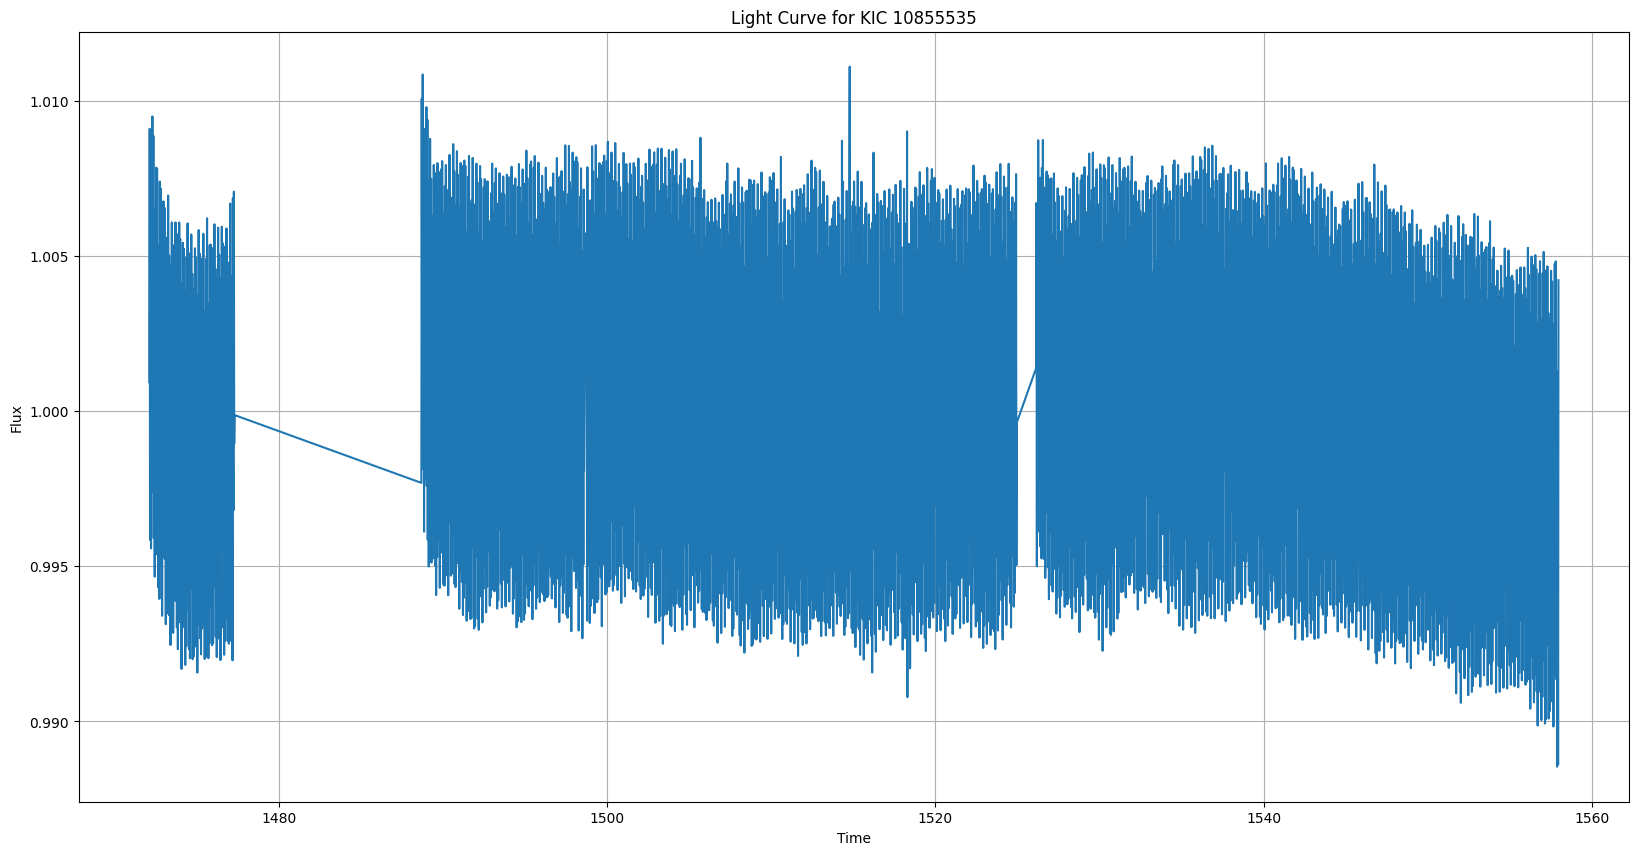

In [57]:
import random

# Sample a random KIC value from the list
random_kic = int(random.choice(list(lc_dict.keys())))
print(f"Random KIC: {random_kic}")

# Plot the light curve for the sampled KIC
plotLCFromDict(lc_dict, random_kic)
